In [ ]:
import pandas as pd
import sys
from pathlib import Path

current_path = Path.cwd()
PROJECT_ROOT = None

for p in [current_path, current_path.parent, current_path.parent.parent]:
    if (p / "rainfall_acoustic_classification").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT:
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT)) # insert(0) garante prioridade absoluta
    print(f"✅ Raiz do projeto adicionada ao sys.path: {PROJECT_ROOT}")
else:
    print("❌ ERRO: Não foi possível encontrar a raiz do projeto.")

from rainfall_acoustic_classification.ingestion import (
    scan_files, extract_filename_metadata, merge_ground_truth,
    discard_files, undersample_1_to_1, split_dataset
)
from rainfall_acoustic_classification.utils import save_checkpoint
from rainfall_acoustic_classification.visualization import VisualizationEngine
from rainfall_acoustic_classification.visualization.plots import (
    plot_styled_donut, 
    plot_styled_stacked_bar, 
    plot_temporal_log_distribution, 
    plot_custom_matrix
)

# Configurações do Dataset (Exemplo IDSM)
RAW_DIR = Path(r"C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-Rainfall\RAC-semiurban-forest-ML-2026\data\raw\Chavascal") 
AUDIT_PATH = PROJECT_ROOT/"data"/"raw"/"df_ch.csv"
AUDIT_MAPPING = {
            'date': 'timestamp', 
            'filename': 'file_name', 
            'total_rain': 'mm_5min', 
            'rain_class': 'category',
            'period': 'period'
        }
CHAVASCAL_REGEX = (
    r"(?P<recorder>[A-Z0-9]+)_"
    r"(?P<year>\d{4})(?P<month>\d{2})(?P<day>\d{2})_"
    r"(?P<hour>\d{2})(?P<minute>\d{2})(?P<second>\d{2})"
    r"(?:_?(?P<rain_mm_str>\d+-\d+))?"       # Optional: Rain MM (e.g., 0-2)
    r"(?:_?(?P<category>[a-zA-Z0-9-]+))?" # FIX: Strictly exclude underscores
)
ALL_CLASSES = ['No Rain', 'Light', 'Moderate', 'Heavy', 'Violent', 'Unlabeled']
RAIN_CLASSES = ['Light', 'Moderate', 'Heavy', 'Violent']
WMO_CLASSES = ['no-rain', 'light', 'moderate', 'heavy', 'violent']

✅ Raiz do projeto adicionada ao sys.path: c:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-Rainfall\RAC-semiurban-forest-ML-2026


# Ingestion

In [2]:
raw_data_output_dir = PROJECT_ROOT / "data" / "raw"

metadata_file_path = raw_data_output_dir / "chavascal_metadata.csv"
merged_file_path = raw_data_output_dir / "chavascal_merged.csv"

df_raw = (
    scan_files(RAW_DIR)
    .pipe(extract_filename_metadata, regex_pattern=CHAVASCAL_REGEX)
    .pipe(save_checkpoint, file_path=metadata_file_path, index=False)
    .pipe(merge_ground_truth, audit_path=AUDIT_PATH, gt_mapping=AUDIT_MAPPING, no_overwrite=['period'])
    .pipe(save_checkpoint, file_path=merged_file_path, index=False)
)

## Checking

In [3]:
df_metadata = pd.read_csv(metadata_file_path)
df_merged = pd.read_csv(merged_file_path)

count_metadata = df_metadata['category'].value_counts()
print('df_metadata:')
print(count_metadata, '\n')

count_merged = df_merged['category'].value_counts()
print('df_merged:')
print(count_merged, '\n')

df_metadata:
category
no-rain      5534
moderate       69
light          55
heavy          51
unlabeled      33
violent         9
Name: count, dtype: int64 

df_merged:
category
no-rain      5534
moderate       69
light          55
heavy          51
unlabeled      33
violent         9
Name: count, dtype: int64 



In [11]:
df_metadata.groupby(['category']).sample(3)

,file_name,file_path,extension,location,recorder,year,month,day,hour,minute,second,category,mm_5min,mm_hr,timestamp,period
7,SMM11307_20240113_051000_1-2_heavy_night.wav,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,Chavascal,SMM11307,2024,1,13,5,10,0,heavy,1.2,14.4,2024-01-13 05:10:00,overnight
38,SMM11307_20240518_161500_1-8_heavy_afternoon.wav,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,Chavascal,SMM11307,2024,5,18,16,15,0,heavy,1.8,21.6,2024-05-18 16:15:00,afternoon
35,SMM11307_20240122_024000_2-8_heavy_night.wav,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,Chavascal,SMM11307,2024,1,22,2,40,0,heavy,2.8,33.6,2024-01-22 02:40:00,overnight
73,SMM11307_20240122_020500_0-2_light_night.wav,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,Chavascal,SMM11307,2024,1,22,2,5,0,light,0.2,2.4,2024-01-22 02:05:00,overnight
78,SMM11307_20240122_030500_0-2_light_night.wav,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,Chavascal,SMM11307,2024,1,22,3,5,0,light,0.2,2.4,2024-01-22 03:05:00,overnight
81,SMM11307_20240518_165000_0-2_light_afternoon.wav,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,Chavascal,SMM11307,2024,5,18,16,50,0,light,0.2,2.4,2024-05-18 16:50:00,afternoon
162,SMM11307_20240524_012000_0-6_moderate_night.wav,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,Chavascal,SMM11307,2024,5,24,1,20,0,moderate,0.6,7.2,2024-05-24 01:20:00,overnight
155,SMM11307_20240520_233000_0-6_moderate_night.wav,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,Chavascal,SMM11307,2024,5,20,23,30,0,moderate,0.6,7.2,2024-05-20 23:30:00,night
134,SMM11307_20240113_094500_0-6_moderate_morning.wav,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,Chavascal,SMM11307,2024,1,13,9,45,0,moderate,0.6,7.2,2024-01-13 09:45:00,morning
3318,SMM11307_20240518_092000_0-0_no-rain_morning.wav,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,Chavascal,SMM11307,2024,5,18,9,20,0,no-rain,0.0,0.0,2024-05-18 09:20:00,morning


In [12]:
df_merged.groupby(['category']).sample(3)

,file_name,timestamp,period,mm_5min,mm_hr,category,recorder,location,file_path,extension,year,month,day,hour,minute,second,wet
25,SMM11307_20240113_094000_1-6_heavy_morning.wav,2024-01-13 09:40:00,morning,1.6,19.2,heavy,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,1,13,9,40,0,NaN
8,SMM11307_20240113_052000_1-6_heavy_night.wav,2024-01-13 05:20:00,overnight,1.6,19.2,heavy,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,1,13,5,20,0,NaN
15,SMM11307_20240113_071500_4-0_heavy_morning.wav,2024-01-13 07:15:00,morning,4.0,48.0,heavy,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,1,13,7,15,0,NaN
53,SMM11307_20240113_034000_0-2_light_night.wav,2024-01-13 03:40:00,overnight,0.2,2.4,light,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,1,13,3,40,0,NaN
70,SMM11307_20240118_235500_0-2_light_night.wav,2024-01-18 23:55:00,night,0.2,2.4,light,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,1,18,23,55,0,NaN
68,SMM11307_20240113_203000_0-2_light_night.wav,2024-01-13 20:30:00,night,0.2,2.4,light,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,1,13,20,30,0,NaN
107,SMM11307_20240113_003000_0-4_moderate_night.wav,2024-01-13 00:30:00,overnight,0.4,4.8,moderate,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,1,13,0,30,0,NaN
127,SMM11307_20240113_081000_0-8_moderate_morning.wav,2024-01-13 08:10:00,morning,0.8,9.6,moderate,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,1,13,8,10,0,NaN
135,SMM11307_20240115_193000_0-6_moderate_night.wav,2024-01-15 19:30:00,night,0.6,7.2,moderate,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,1,15,19,30,0,True
383,SMM11307_20240113_120000_0-0_no-rain_afternoon...,2024-01-13 12:00:00,afternoon,0.0,0.0,no-rain,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,1,13,12,0,0,False


# Visualization

In [3]:
output_dir = PROJECT_ROOT / "reports" / "figures" / "Chavascal" / 'raw'

engine = VisualizationEngine(output_dir=output_dir)
df_raw_viz = df_raw.copy()

# Title padronization
df_raw_viz['category'] = (
    df_raw['category']
    .replace({
        'no-rain': 'No Rain',
        'light': 'Light', 
        'moderate': 'Moderate', 
        'heavy': 'Heavy', 
        'violent': 'Violent', 
        'unlabeled': 'Unlabeled'
        })
).str.title()

# 'mounth_label' creation
df_raw_viz['timestamp'] = pd.to_datetime(df_raw_viz['timestamp'])
unique_periods = df_raw_viz['timestamp'].dt.to_period('M').drop_duplicates()
sorted_periods = unique_periods.sort_values()
months_order = sorted_periods.dt.strftime('%b %Y').tolist()

df_raw_viz['month_label'] = pd.Categorical(
    df_raw_viz['timestamp'].dt.strftime('%b %Y'), 
    categories=months_order, 
    ordered=True
)

df_raw_viz['category'] = pd.Categorical(df_raw_viz['category'], categories=ALL_CLASSES, ordered=True)

## Dataset Distributions

10:59:25 - [VizEngine] - INFO - Figure saved: chavascal_donut_all.pdf
10:59:25 - [VizEngine] - INFO - Figure saved: chavascal_donut_all.png
10:59:25 - [VizEngine] - INFO - Figure saved: chavascal_stacked_rain.pdf
10:59:25 - [VizEngine] - INFO - Figure saved: chavascal_stacked_rain.png


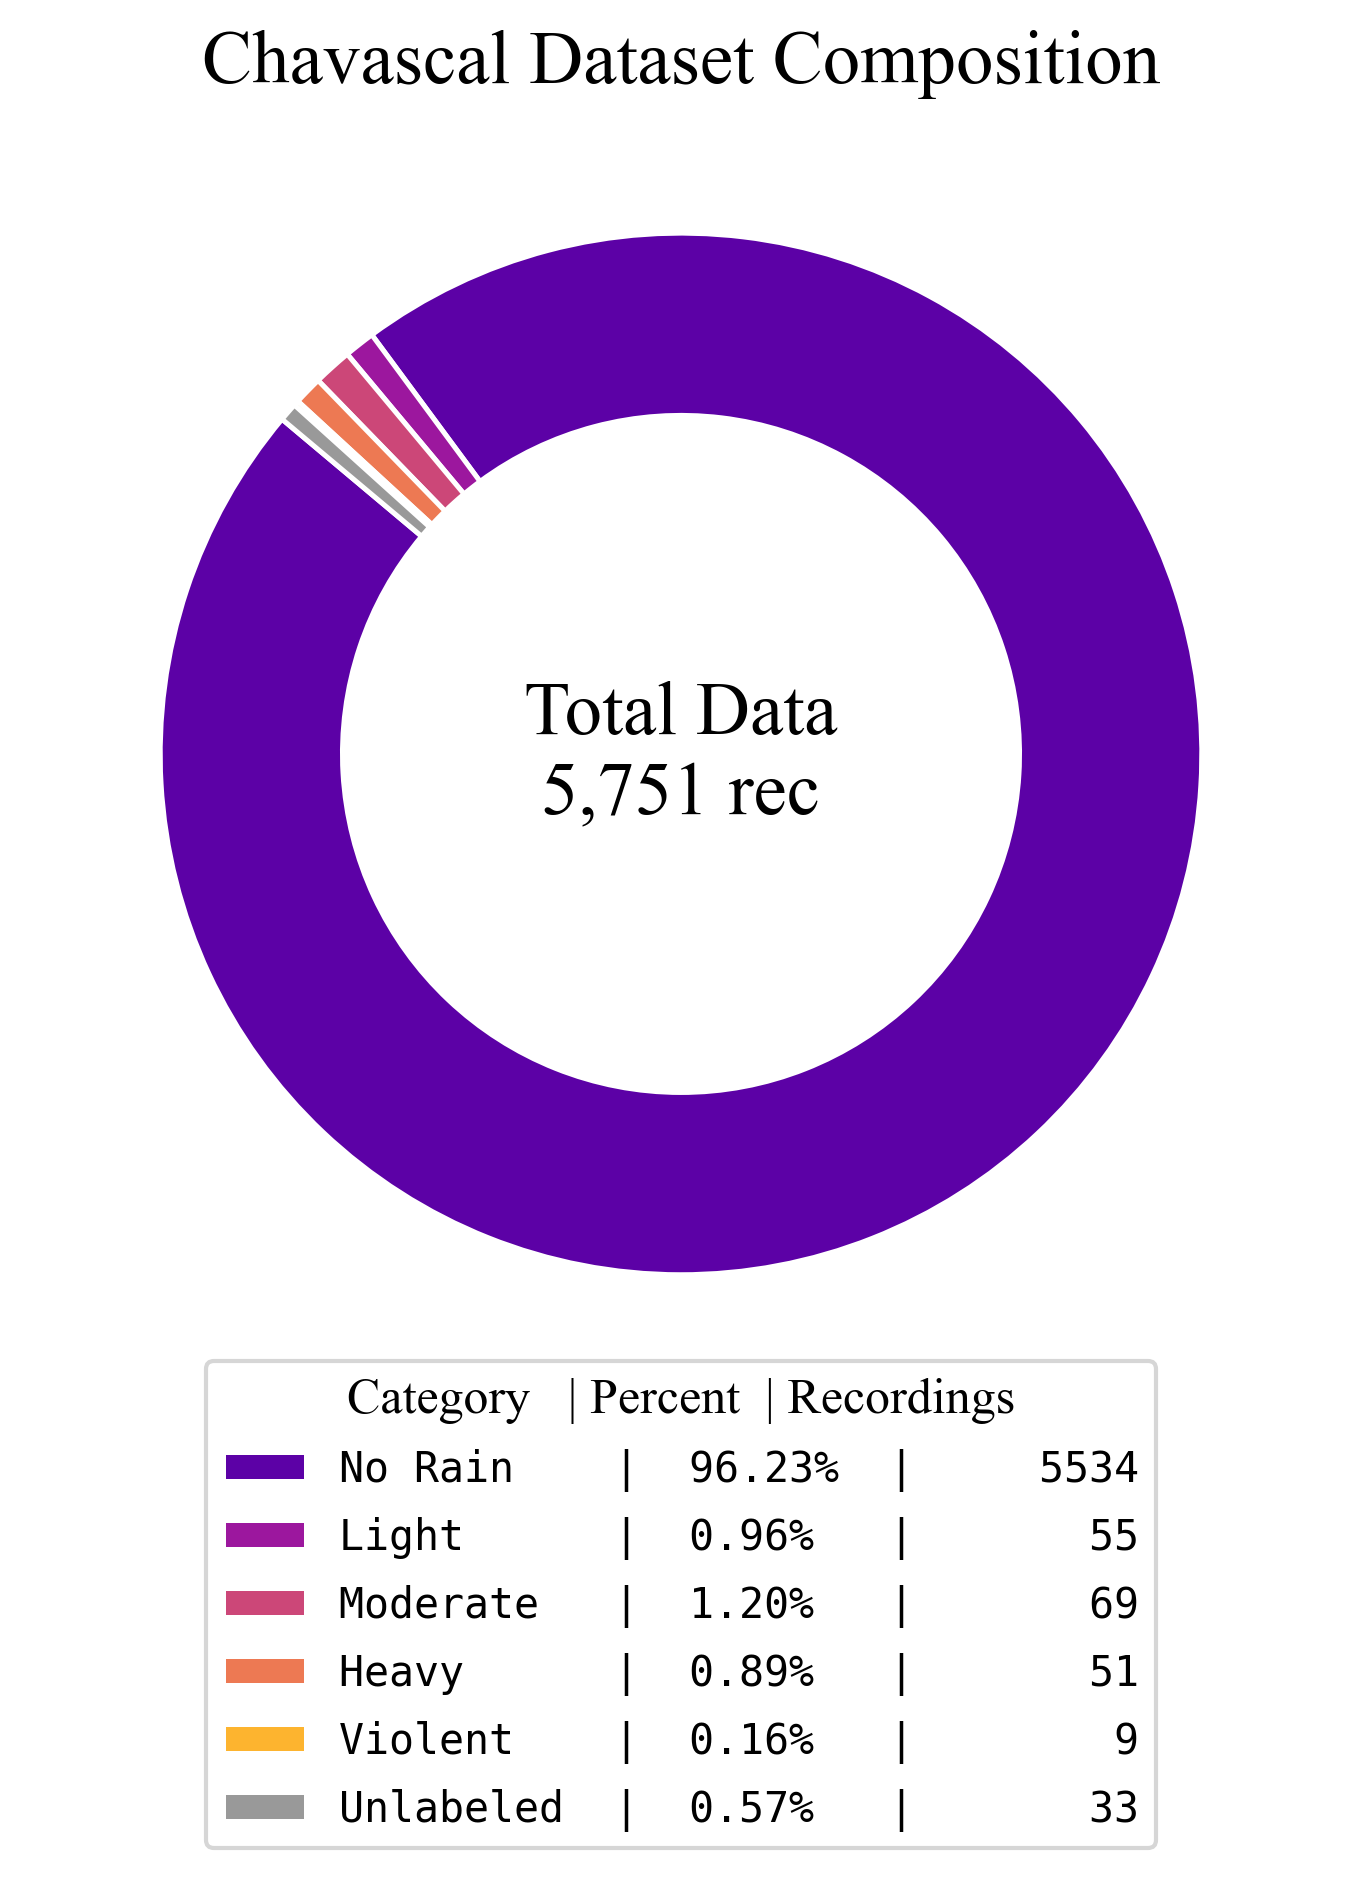

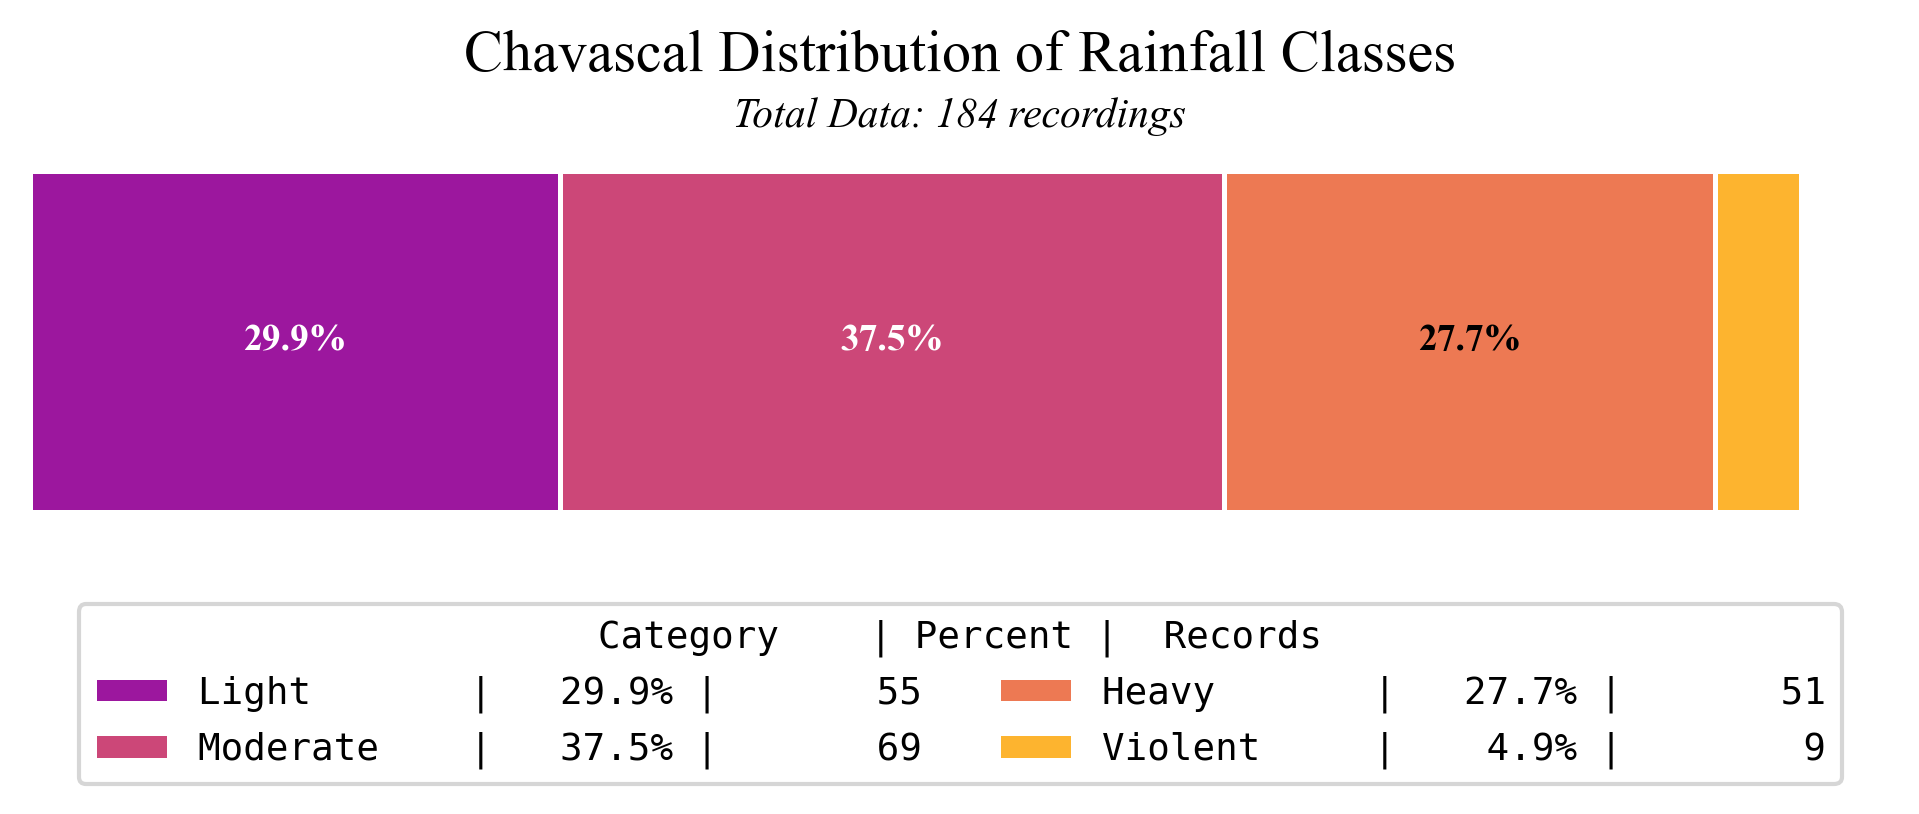

In [19]:
fig_donut_all = plot_styled_donut(df_raw_viz, engine, ALL_CLASSES, "Chavascal Dataset Composition")
engine.save_figure(fig_donut_all, "chavascal_donut_all")

fig_bar_rain = plot_styled_stacked_bar(df_raw_viz, engine, RAIN_CLASSES, "Chavascal Distribution of Rainfall Classes")
engine.save_figure(fig_bar_rain, "chavascal_stacked_rain")

## Monthly Distribuiton

11:01:03 - [VizEngine] - INFO - Figure saved: Chavascal_monthly_distribution_bars.pdf
11:01:03 - [VizEngine] - INFO - Figure saved: Chavascal_monthly_distribution_bars.png


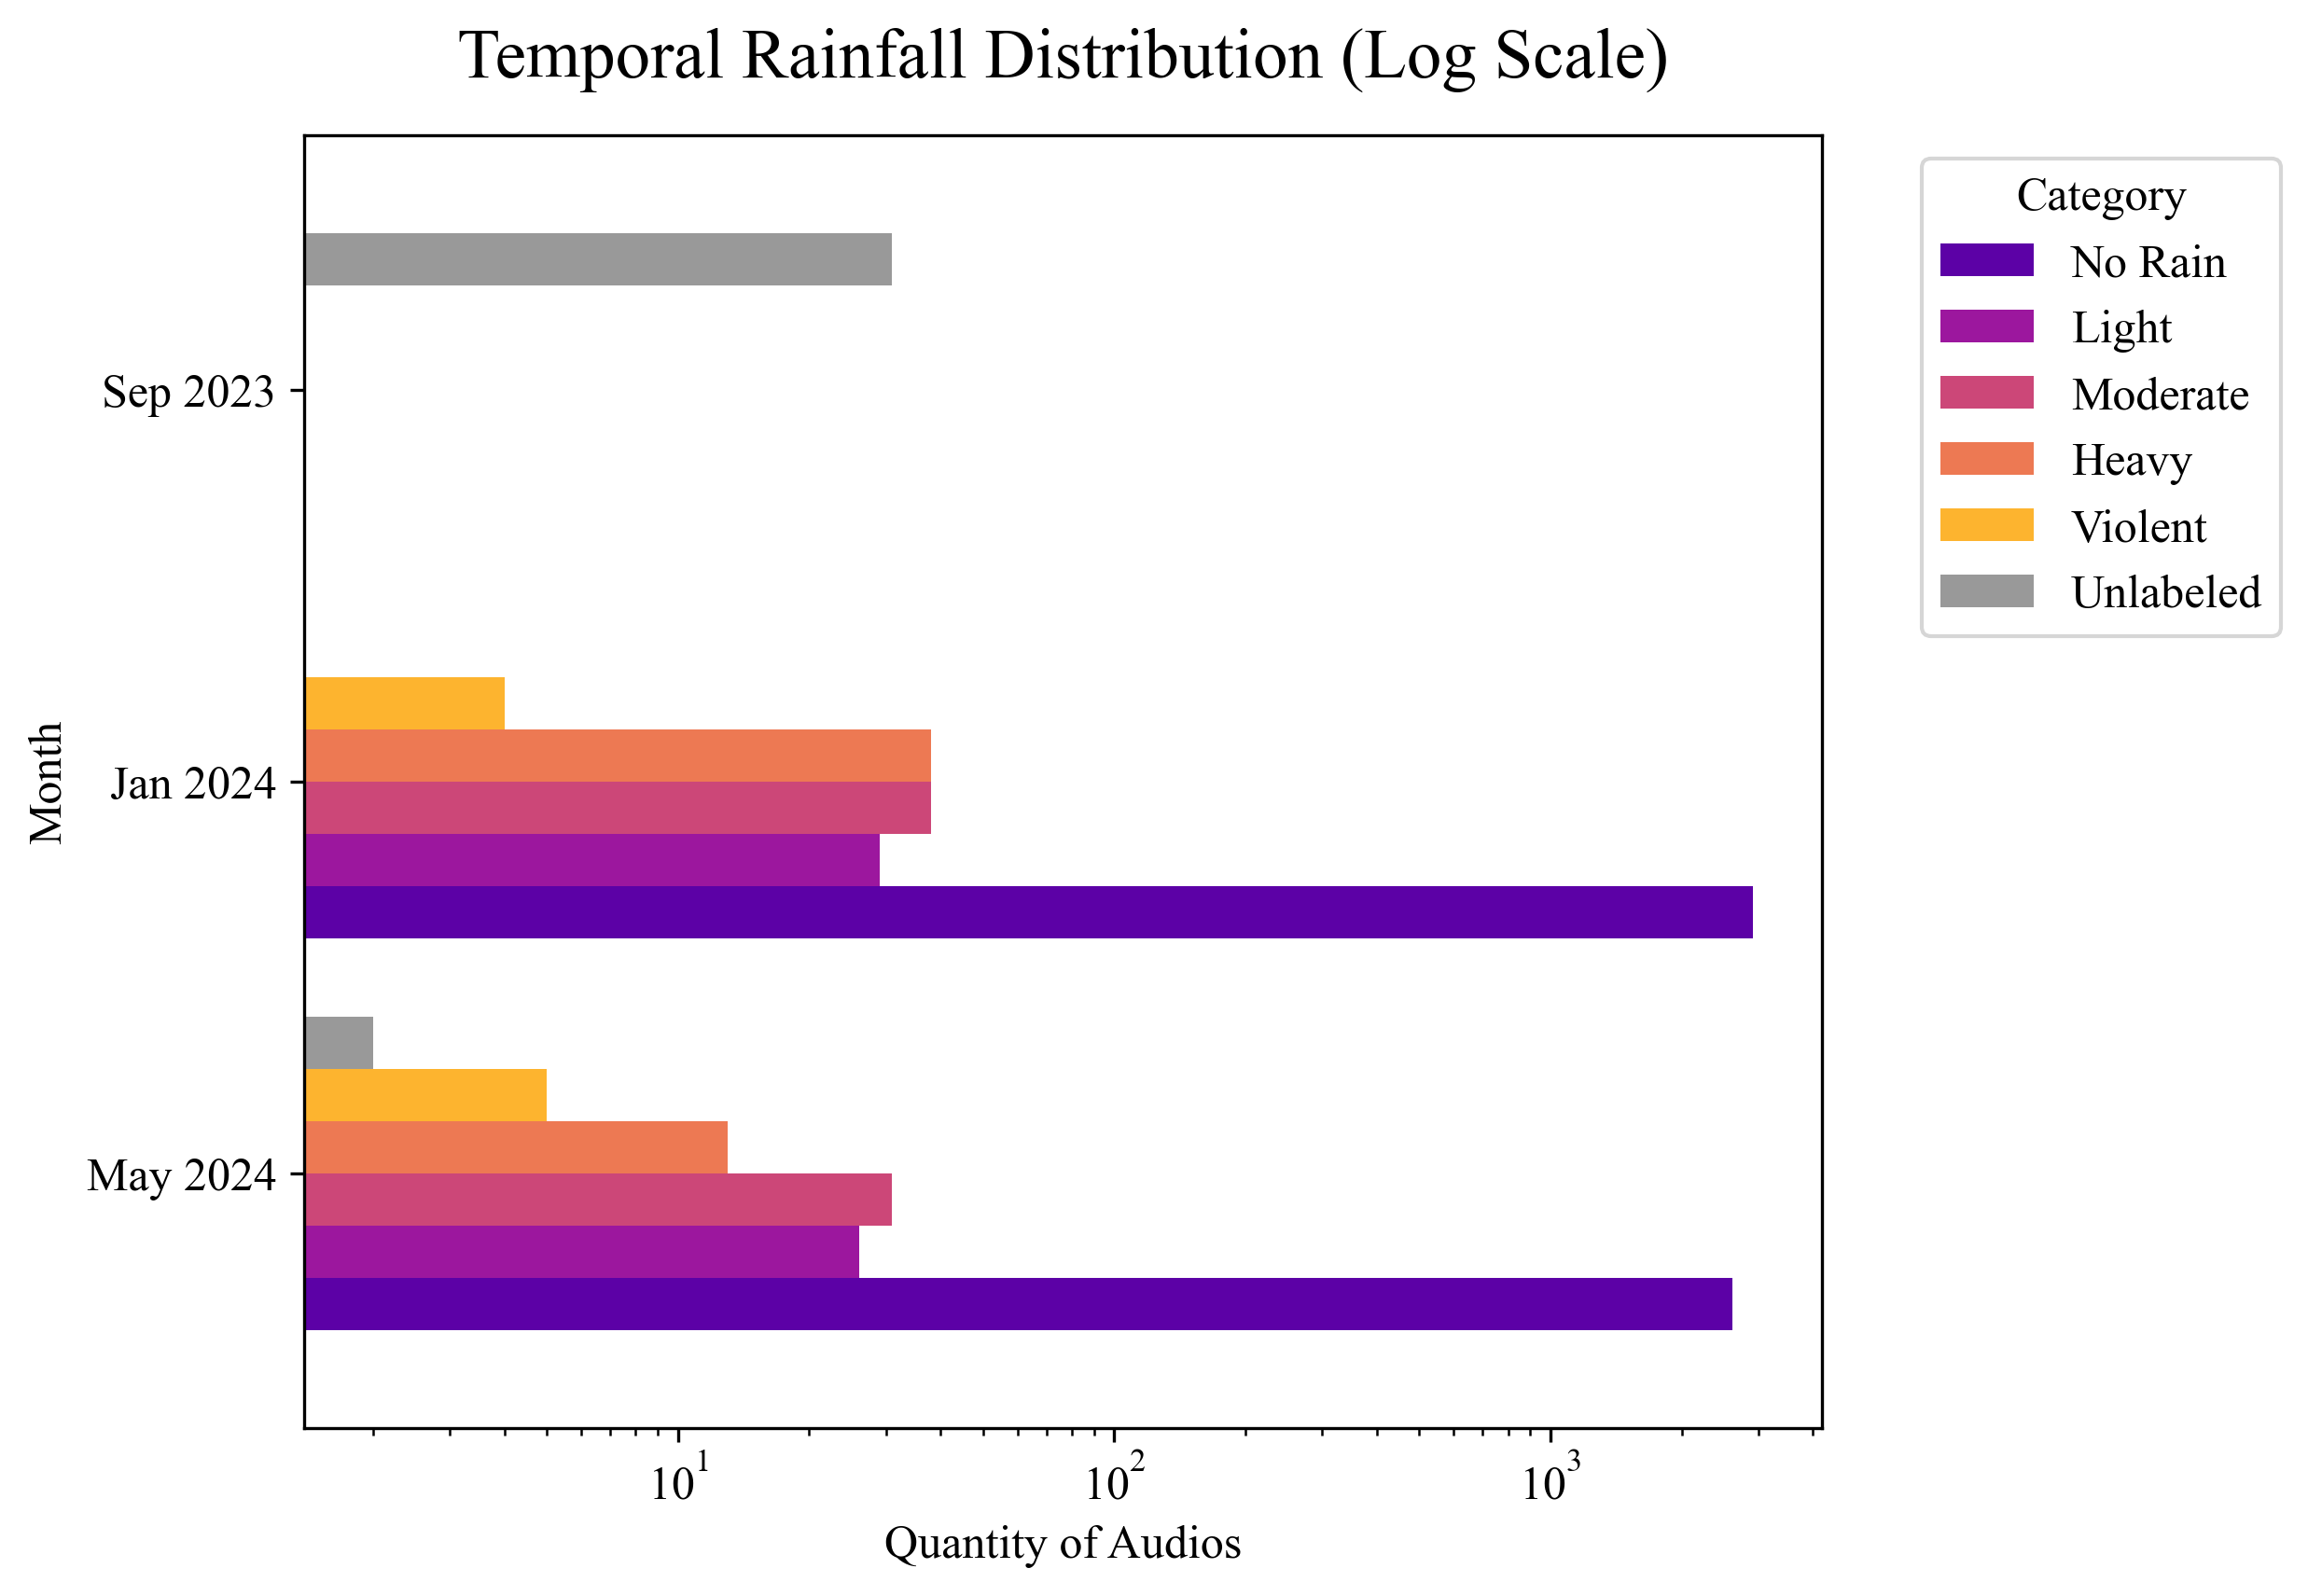

In [4]:
fig_temporal = plot_temporal_log_distribution(df_raw_viz, engine)
engine.save_figure(fig_temporal, "Chavascal_monthly_distribution_bars")

## Monthly Percentages

11:03:47 - [VizEngine] - INFO - Figure saved: chavascal_matrix_percentages_all.pdf
11:03:47 - [VizEngine] - INFO - Figure saved: chavascal_matrix_percentages_all.png
11:03:48 - [VizEngine] - INFO - Figure saved: chavascal_matrix_percentages_rain.pdf
11:03:48 - [VizEngine] - INFO - Figure saved: chavascal_matrix_percentages_rain.png


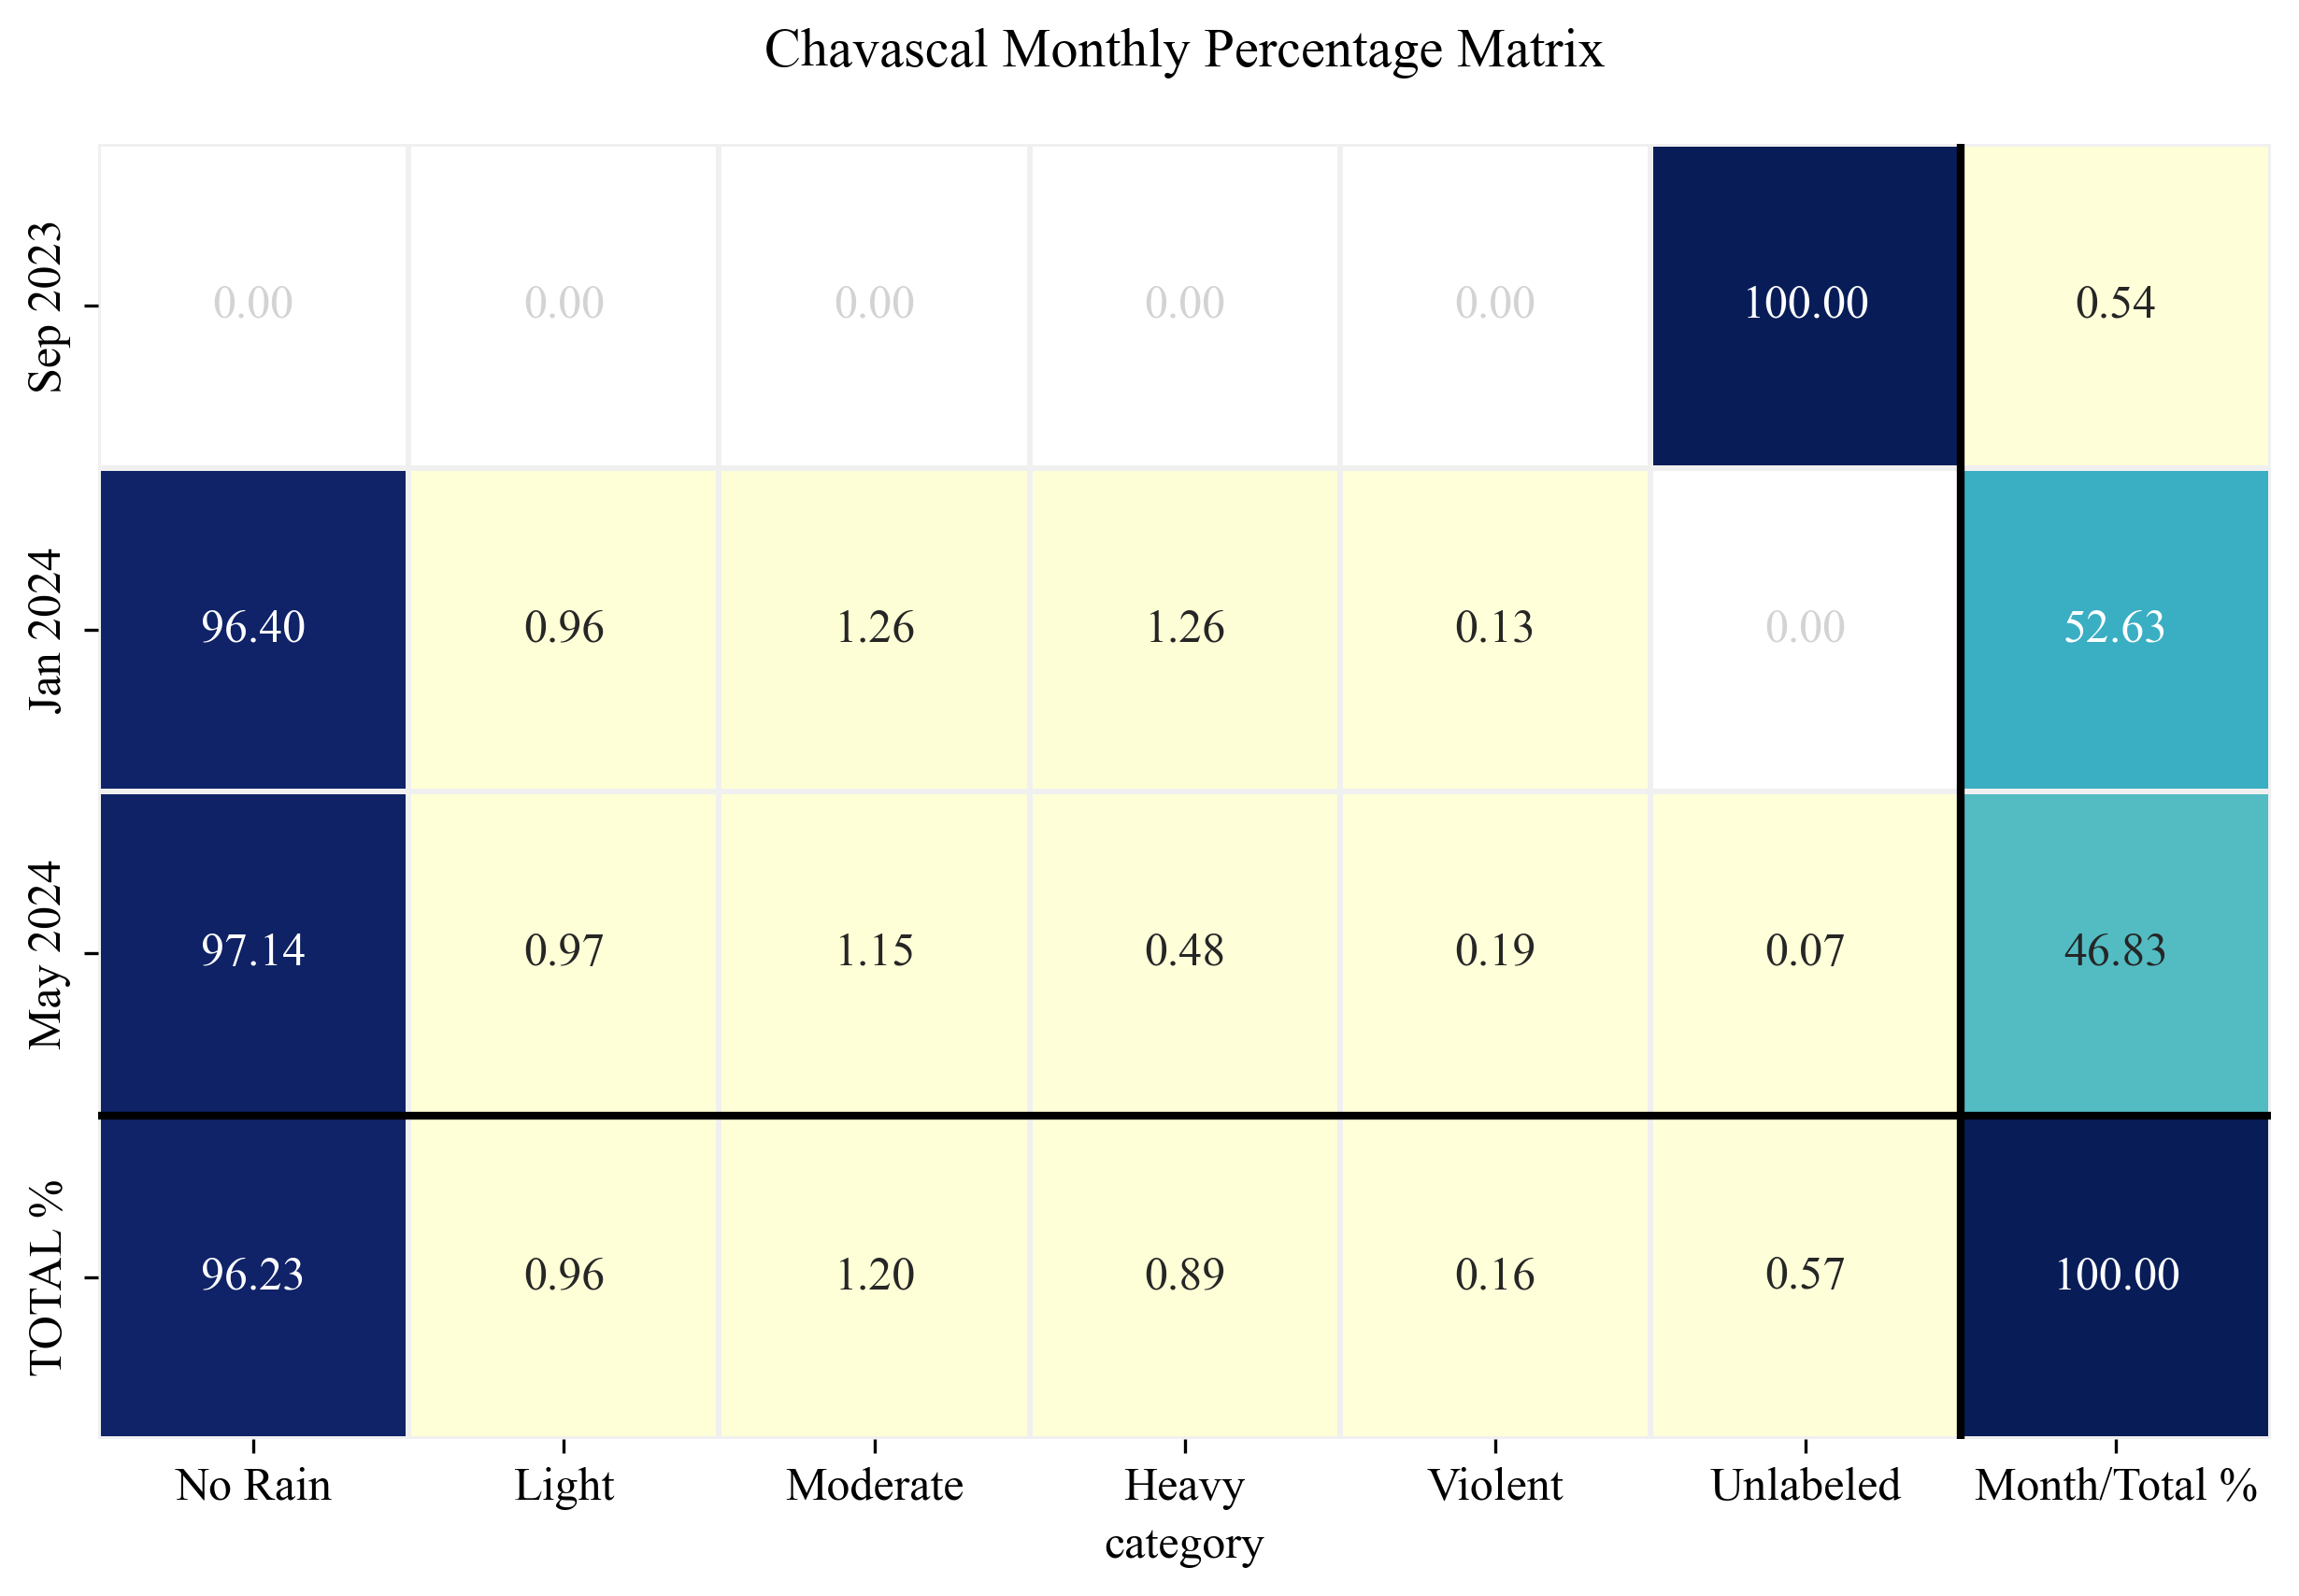

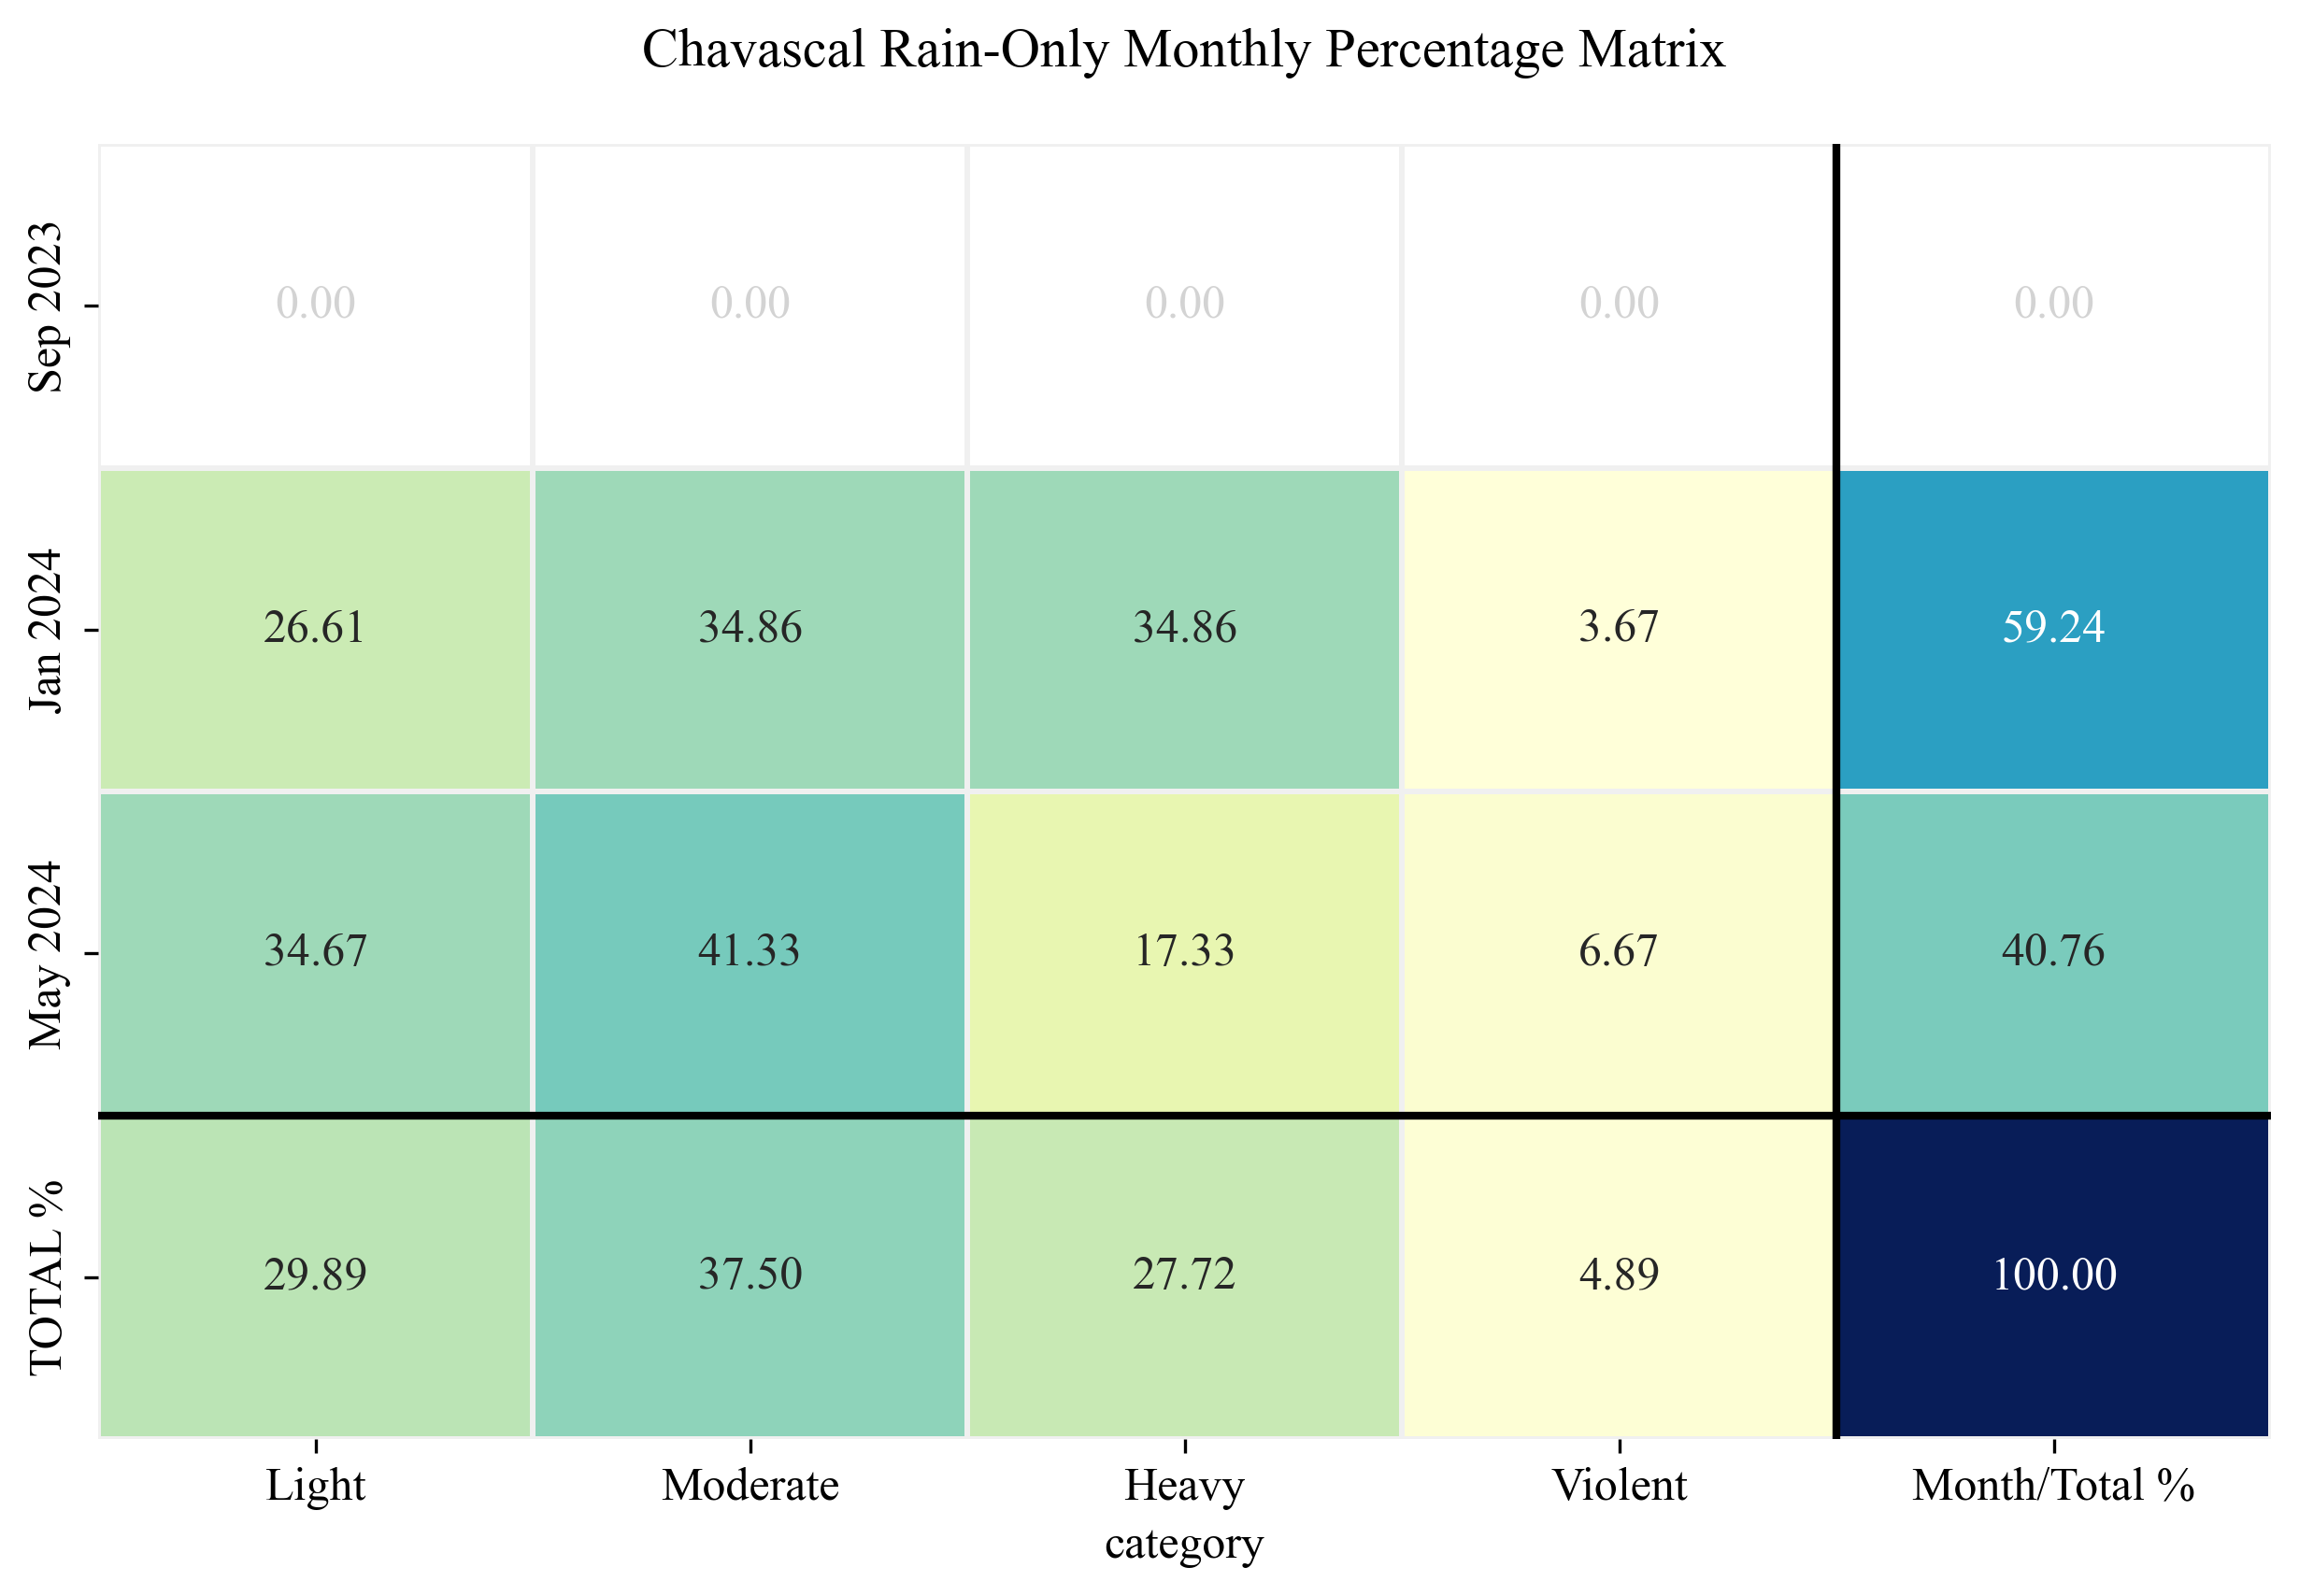

In [7]:
# All dataset
months_order = df_raw_viz['month_label'].cat.categories

matrix_p = pd.crosstab(df_raw_viz['month_label'], df_raw_viz['category'], normalize='index', dropna=False) * 100
month_weights = (df_raw_viz['month_label'].value_counts(normalize=True).reindex(months_order) * 100)
matrix_p['Month/Total %'] = month_weights

total_class_p = (df_raw_viz['category'].value_counts(normalize=True).reindex(ALL_CLASSES) * 100).to_frame().T
total_class_p.index = ['TOTAL %']
total_class_p['Month/Total %'] = 100.0
matrix_p_final = pd.concat([matrix_p, total_class_p])

fig_matrix_p = plot_custom_matrix(matrix_p_final, "Chavascal Monthly Percentage Matrix", fmt=".2f")
engine.save_figure(fig_matrix_p, "chavascal_matrix_percentages_all")


# Only Rain data
df_rain = df_raw_viz[df_raw_viz['category'].isin(RAIN_CLASSES)].copy()
df_rain['category'] = df_rain['category'].cat.remove_unused_categories()

matrix_p_rain = pd.crosstab(df_rain['month_label'], df_rain['category'], normalize='index', dropna=False) * 100
month_weights_rain = (df_rain['month_label'].value_counts(normalize=True).reindex(months_order) * 100)
matrix_p_rain['Month/Total %'] = month_weights_rain

total_rain_p = (df_rain['category'].value_counts(normalize=True).reindex(RAIN_CLASSES) * 100).to_frame().T
total_rain_p.index = ['TOTAL %']
total_rain_p['Month/Total %'] = 100.0
matrix_p_rain_final = pd.concat([matrix_p_rain, total_rain_p])

fig_matrix_p_rain = plot_custom_matrix(matrix_p_rain_final, "Chavascal Rain-Only Monthly Percentage Matrix", fmt=".2f")
engine.save_figure(fig_matrix_p_rain, "chavascal_matrix_percentages_rain")

# Curation

In [15]:
curated_file_path = PROJECT_ROOT / "data" / "raw" / "chavascal_curated.csv"
one_to_one_file_path = PROJECT_ROOT / "data" / "raw" / "chavascal_1_to_1.csv"

df_cleaned = (
    df_raw
    .pipe(discard_files, discard_rules=[
        "category == 'Unlabeled'",
        "category.isnull() or mm_5min.isnull() or mm_hr.isnull()",
        "wet == True and mm_5min == 0", 
        "wet == False and mm_5min > 0" 
    ])
    .pipe(save_checkpoint, file_path=curated_file_path, index=False)
    .pipe(undersample_1_to_1, target_col='category', anchor_classes=WMO_CLASSES[1:5], sample_classes=[WMO_CLASSES[0]])
    .pipe(save_checkpoint, file_path=one_to_one_file_path, index=False)
)

11:25:55 - [DataCurator] - INFO - Applying 4 discard rule(s)...
11:25:55 - [DataCurator] - INFO - Curation complete. Remaining records: 5591 (Original: 5751).
11:25:55 - [DataBalancer] - INFO - Initiating 1:1 undersamplig on column 'category'.
11:25:55 - [DataBalancer] - INFO - Anchor group size: 184 | Pool group size: 5407
11:25:55 - [DataBalancer] - INFO - Balanced Dataset generated: 368 total records.


## Checking

In [16]:
df_curated = pd.read_csv(curated_file_path)
df_one_to_one = pd.read_csv(one_to_one_file_path)

count_raw = df_raw['category'].value_counts()
print('df_raw:')
print(count_raw, '\n')

count_curated = df_curated['category'].value_counts()
print('df_curated:')
print(count_curated, '\n')

count_one_to_one = df_one_to_one['category'].value_counts()
print('df_1_to_1:')
print(count_one_to_one, '\n')

df_raw:
category
no-rain      5534
moderate       69
light          55
heavy          51
unlabeled      33
violent         9
Name: count, dtype: int64 

df_curated:
category
no-rain     5407
moderate      69
light         55
heavy         51
violent        9
Name: count, dtype: int64 

df_1_to_1:
category
no-rain     184
moderate     69
light        55
heavy        51
violent       9
Name: count, dtype: int64 



## Stratified Split

In [18]:
split_file_path = PROJECT_ROOT / "data" / "splits"

train_file_path = split_file_path / "chavascal_train.csv"
val_file_path = split_file_path / "chavascal_val.csv"
test_file_path = split_file_path / "chavascal_test.csv"


df_train, df_val, df_test = split_dataset(
    df_cleaned, 
    test_size=0.1, 
    val_size=0.1, 
    stratify_cols=['category']
)


df_train.to_csv(train_file_path, index=False)
df_val.to_csv(val_file_path, index=False)
df_test.to_csv(test_file_path, index=False)

# Checking

In [30]:
count_train = df_train['category'].value_counts()
print('TRAIN:')
print(count_train)
print("Total Samples    ", len(df_train['category']), '\n')

count_val = df_val['category'].value_counts()
print('VALIDATION:')
print(count_val)
print("Total Samples    ", len(df_val['category']), '\n')

count_test = df_test['category'].value_counts()
print('TEST')
print(count_test)
print("Total Samples    ", len(df_test['category']), '\n')

total = len(df_test['category']) + len(df_val['category']) + len(df_train['category'])

print("PERCENTAGES:")
print("Train         ", round((len(df_train['category'])/total), 2))
print("Validation    ", round((len(df_val['category'])/total), 2))
print("Test          ", round((len(df_test['category'])/total), 2))



TRAIN:
category
no-rain     147
moderate     55
light        44
heavy        41
violent       7
Name: count, dtype: int64
Total Samples     294 

VALIDATION:
category
no-rain     19
moderate     7
light        5
heavy        5
violent      1
Name: count, dtype: int64
Total Samples     37 

TEST
category
no-rain     18
moderate     7
light        6
heavy        5
violent      1
Name: count, dtype: int64
Total Samples     37 

PERCENTAGES:
Train          0.8
Validation     0.1
Test           0.1


In [34]:
df_train.groupby(['category']).sample()

,file_name,timestamp,period,mm_5min,mm_hr,category,recorder,location,file_path,extension,year,month,day,hour,minute,second,wet
16,SMM11307_20240112_133000_1-2_heavy_afternoon.wav,2024-01-12 13:30:00,afternoon,1.2,14.4,heavy,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,01,12,13,30,00,NaN
355,SMM11307_20240524_155000_0-2_light_afternoon.wav,2024-05-24 15:50:00,afternoon,0.2,2.4,light,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,05,24,15,50,00,NaN
364,SMM11307_20240112_225500_0-4_moderate_night.wav,2024-01-12 22:55:00,night,0.4,4.8,moderate,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,01,12,22,55,00,NaN
242,SMM11307_20240115_023500_0-0_no-rain_night.wav,2024-01-15 02:35:00,overnight,0.0,0.0,no-rain,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,01,15,02,35,00,NaN
141,SMM11307_20240525_142000_4-6_violent_afternoon...,2024-05-25 14:20:00,afternoon,4.6,55.2,violent,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,05,25,14,20,00,NaN


In [35]:
df_val.groupby(['category']).sample()

,file_name,timestamp,period,mm_5min,mm_hr,category,recorder,location,file_path,extension,year,month,day,hour,minute,second,wet
158,SMM11307_20240113_083000_1-6_heavy_morning.wav,2024-01-13 08:30:00,morning,1.6,19.2,heavy,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,01,13,08,30,00,NaN
19,SMM11307_20240526_055500_0-2_light_night.wav,2024-05-26 05:55:00,overnight,0.2,2.4,light,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,05,26,05,55,00,NaN
44,SMM11307_20240113_030500_0-6_moderate_night.wav,2024-01-13 03:05:00,overnight,0.6,7.2,moderate,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,01,13,03,05,00,NaN
208,SMM11307_20240522_123000_0-0_no-rain_afternoon...,2024-05-22 12:30:00,afternoon,0.0,0.0,no-rain,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,05,22,12,30,00,NaN
174,SMM11307_20240113_031500_5-6_violent_night.wav,2024-01-13 03:15:00,overnight,5.6,67.2,violent,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,01,13,03,15,00,NaN


In [37]:
df_test.groupby(['category']).sample()

,file_name,timestamp,period,mm_5min,mm_hr,category,recorder,location,file_path,extension,year,month,day,hour,minute,second,wet
82,SMM11307_20240113_051000_1-2_heavy_night.wav,2024-01-13 05:10:00,overnight,1.2,14.4,heavy,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,01,13,05,10,00,NaN
317,SMM11307_20240523_051000_0-2_light_night.wav,2024-05-23 05:10:00,overnight,0.2,2.4,light,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,05,23,05,10,00,NaN
205,SMM11307_20240113_063500_0-6_moderate_morning.wav,2024-01-13 06:35:00,morning,0.6,7.2,moderate,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,01,13,06,35,00,NaN
303,SMM11307_20240522_182000_0-0_no-rain_night.wav,2024-05-22 18:20:00,night,0.0,0.0,no-rain,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,05,22,18,20,00,NaN
125,SMM11307_20240525_142500_10-0_violent_afternoo...,2024-05-25 14:25:00,afternoon,10.0,120.0,violent,SMM11307,Chavascal,C:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-...,.wav,2024,05,25,14,25,00,NaN
